<a href="https://colab.research.google.com/github/cristianzucconi2-web/deep_learning/blob/main/phi3_5_non_fine_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-4ocg0lza/unsloth_774d1e236166451982250159bf71c3c3
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-4ocg0lza/unsloth_774d1e236166451982250159bf71c3c3
  Resolved https://github.com/unslothai/unsloth.git to commit 13928b5f0ed215667f8c54abe1b975bbd6ab5ce5
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 326.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 437.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 346.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.4/418.4 kB 430.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 261.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 233.2 MB/s eta 0:00:

model.safetensors:   0%|          | 0.00/2.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/140 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

Cloning into 'SemEval2018-Task3'...
remote: Enumerating objects: 315, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 315 (delta 0), reused 0 (delta 0), pack-reused 312 (from 1)
Receiving objects: 100% (315/315), 681.37 KiB | 14.81 MiB/s, done.
Resolving deltas: 100% (142/142), done.
🚀 Avvio Benchmark Phi-3.5 su 784 tweet...


  0%|          | 0/784 [00:00<?, ?it/s]Both `max_new_tokens` (=2) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, Fu


======= 🧊 RISULTATI PHI-3.5 BASE =======
ACCURACY: 58.04%

REPORT DETTAGLIATO:
              precision    recall  f1-score   support

 Non Ironico       0.99      0.31      0.47       473
     Ironico       0.49      1.00      0.65       311

    accuracy                           0.58       784
   macro avg       0.74      0.65      0.56       784
weighted avg       0.79      0.58      0.54       784



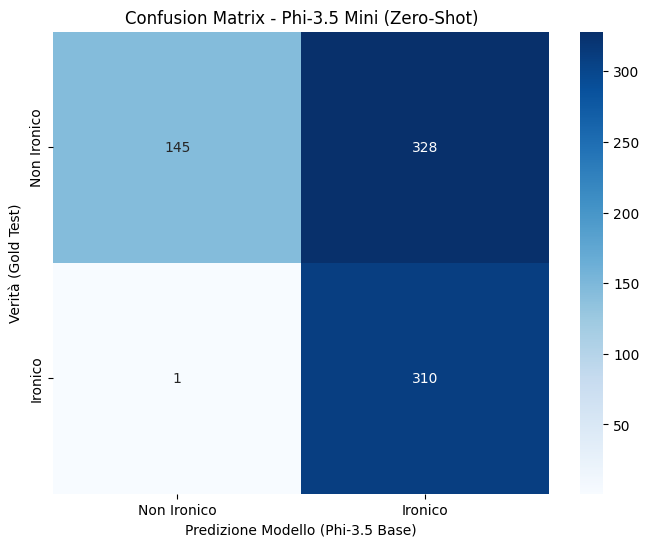

In [1]:
!pip uninstall unsloth -y && pip install --upgrade --no-cache-dir "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"

import torch
from unsloth import FastLanguageModel
import pandas as pd
import re
import os
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

# 1. CARICAMENTO MODELLO PHI-3.5
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Phi-3.5-mini-instruct",
    max_seq_length = 2048,
    load_in_4bit = True,
)
FastLanguageModel.for_inference(model)

# 2. PREPARAZIONE DATASET (Percorsi originali)
if not os.path.exists('SemEval2018-Task3'):
    !git clone https://github.com/Cyvhee/SemEval2018-Task3.git

path_test = 'SemEval2018-Task3/datasets/goldtest_TaskA/SemEval2018-T3_gold_test_taskA_emoji.txt'
test_df = pd.read_csv(path_test, sep='\t')

if len(test_df.columns) == 3:
    test_df.columns = ['index', 'label', 'tweet text']

def clean_tweet(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    return text.strip()

test_df_clean = test_df[test_df['label'].astype(str).str.contains('0|1')].copy()
test_df_clean['tweet text'] = test_df_clean['tweet text'].apply(clean_tweet)
test_df_clean['label'] = test_df_clean['label'].astype(int)

# 3. FUNZIONE DI TEST "ROBUSTA" (Stile Llama 3.2)
def test_phi_base(tweet):
    # Cambiamo leggermente il prompt per forzarlo a rispondere in modo più chiaro
    prompt = f"<|system|>\nYou are a linguistic expert. Answer ONLY with the digit 1 if the tweet is ironic, or 0 if it is not.<|end|>\n<|user|>\nTweet: {tweet}<|end|>\n<|assistant|>\n"

    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            input_ids = inputs.input_ids,
            attention_mask = inputs.attention_mask,
            max_new_tokens = 2, # Diamo spazio per un eventuale spazio + numero
            use_cache = False,  # Stabilità su T4
            pad_token_id = tokenizer.eos_token_id
        )

    # Decodifica solo l'ultimo pezzetto
    risposta = tokenizer.decode(outputs[0][inputs.input_ids.shape[-1]:], skip_special_tokens=True).strip()

    # REGEX ROBUSTA: Cerca il primo 0 o 1 che trova nella risposta
    match = re.search(r'[01]', risposta)
    if match:
        return int(match.group())
    return 0 # Default se non capisce

# 4. ESECUZIONE BENCHMARK
print(f"🚀 Avvio Benchmark Phi-3.5 su {len(test_df_clean)} tweet...")
predictions = []

for text in tqdm(test_df_clean['tweet text']):
    predictions.append(test_phi_base(text))

test_df_clean['pred'] = predictions

# 5. RISULTATI FINALI
y_true = test_df_clean['label'].values
y_pred = test_df_clean['pred'].values
accuracy = (y_true == y_pred).mean()

print(f"\n======= 🧊 RISULTATI PHI-3.5 BASE =======")
print(f"ACCURACY: {accuracy:.2%}")
print("\nREPORT DETTAGLIATO:")
print(classification_report(y_true, y_pred, target_names=['Non Ironico', 'Ironico'], zero_division=0))


import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generazione della Matrice di Confusione
cm = confusion_matrix(y_true, y_pred)

# Visualizzazione Grafica
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non Ironico', 'Ironico'],
            yticklabels=['Non Ironico', 'Ironico'])
plt.xlabel('Predizione Modello (Phi-3.5 Base)')
plt.ylabel('Verità (Gold Test)')
plt.title('Confusion Matrix - Phi-3.5 Mini (Zero-Shot)')
plt.show()